In [45]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.decomposition import TruncatedSVD

import umap


In [10]:
df=pd.read_csv("corpus_zola_paquets_lemm.csv")

In [11]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...


In [12]:
vectorizer = TfidfVectorizer(
    min_df=3,
    max_df=0.8
)
X = vectorizer.fit_transform(df["phrases_lemm"])

In [13]:
kmeans= KMeans(n_clusters=28, 
               random_state=42,
               n_init=10)

df["cluster"] = kmeans.fit_predict(X) +1 

In [14]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm,cluster
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...,24
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...,7
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...,4
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...,26
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...,5


In [15]:
terms = vectorizer.get_feature_names_out()
centres = kmeans.cluster_centers_

for i, centre in enumerate(centres):
    top_indices = centre.argsort()[::-1][:10]
    mots = [terms[j] for j in top_indices]
    print(f"Cluster {i+1} :", " | ".join(mots))

Cluster 1 : million | bourse | cours | action | franc | banque | universelle | argent | affaire | titre
Cluster 2 : travail | vie | peuple | enfant | terre | bonheur | petit | monde | homme | œuvre
Cluster 3 : train | fosse | machine | heure | voie | homme | berline | puits | coup | mineur
Cluster 4 : enfant | mère | fille | femme | petit | vie | cœur | père | jour | bon
Cluster 5 : homme | frère | femme | jeune | petit | affaire | main | porte | monsieur | fine
Cluster 6 : franc | argent | monsieur | fille | femme | bon | père | jour | petit | fortune
Cluster 7 : docteur | monsieur | médecin | enfant | mère | petit | malade | oeil | lit | heure
Cluster 8 : jeune | femme | amant | amour | cœur | pensée | vie | homme | jour | voix
Cluster 9 : saint | église | abbé | autel | monseigneur | prêtre | chapelle | vierge | blanc | cierge
Cluster 10 : coupeau | maman | boutique | zingueur | rue | petit | blanchisseur | jour | verre | vin
Cluster 11 : chambre | lit | heure | main | oeil | petit 

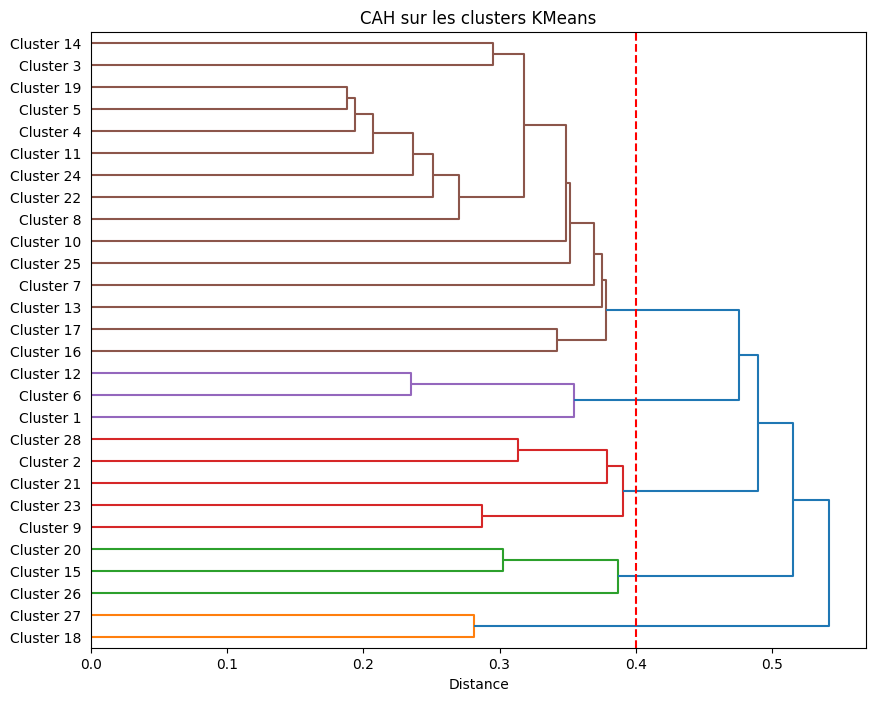

In [ ]:
plt.figure(figsize=(10, 8))
Z = linkage(centres, method='ward')

dendrogram(
    Z,
    labels=[f"Cluster {i+1}" for i in range(kmeans.n_clusters)],
    orientation="right",
    color_threshold=0.40
)

plt.axvline(x=0.40, color="red", linestyle="--")

plt.title("CAH sur les clusters KMeans")
plt.xlabel("Distance")
plt.show()

In [21]:
noms_clusters = {
    1: "L’argent, la bourse et les affaires",
    2: "Le monde du travail et du peuple",
    3: "Les machines, les trajets et la mine",
    4: "L’enfance, la mère et la famille",
    5: "Les liens familiaux et les proches",
    6: "L’argent du quotidien",
    7: "La maladie, le médecin et le corps souffrant",
    8: "L’amour, le désir et les sentiments",
    9: "L’église, les saints et le sacré",
    10: "L’alcool, la boutique et l’univers de L’Assommoir",
    11: "La chambre, le lit et l’intimité du corps",
    12: "Les billets, les dettes et les petites sommes",
    13: "Le magasin, la vente et les clientes",
    14: "La nature, les arbres et le jardin",
    15: "La guerre, les soldats et l’armée",
    16: "Le pouvoir politique et l’Empire",
    17: "Le théâtre, le salon et le monde aristocratique",
    18: "Le curé, la paroisse et la vie religieuse",
    19: "La famille, la terre et le monde paysan",
    20: "Les barricades, les armes et l’affrontement",
    21: "Rome, le pape et le pouvoir religieux",
    22: "Les conversations et les scènes mondaines",
    23: "Le miracle, la grotte et le pèlerinage",
    24: "La rue, le quartier et la ville",
    25: "La peinture, l’atelier et les artistes",
    26: "La République, les insurgés et la politique",
    27: "Le clergé, la soutane et les autorités locales",
    28: "L’école, les élèves et l’instruction"
}

In [22]:
df["nom_cluster"] = df["cluster"].map(noms_clusters)

In [23]:
df[["cluster", "nom_cluster", "phrases_paquet"]].head()

,cluster,nom_cluster,phrases_paquet
0,24,"La rue, le quartier et la ville",Dans la chaleur de l’ardente après-midi de jui...
1,7,"La maladie, le médecin et le corps souffrant","Mais il dut prendre une chaise, la planche du ..."
2,4,"L’enfance, la mère et la famille","Oh! Monsieur, la religion n’a jamais fait de m..."
3,26,"La République, les insurgés et la politique","De face, dans son visage séché, ses yeux garda..."
4,5,Les liens familiaux et les proches,s’écria la jeune fille. Mais elle était lancée...


In [24]:
for i, centre in enumerate(centres, start=1):
    top_indices = centre.argsort()[::-1][:10]
    mots = [terms[j] for j in top_indices]
    print(f"Cluster {i} - {noms_clusters[i]} :", " | ".join(mots))

Cluster 1 - L’argent, la bourse et les affaires : million | bourse | cours | action | franc | banque | universelle | argent | affaire | titre
Cluster 2 - Le monde du travail et du peuple : travail | vie | peuple | enfant | terre | bonheur | petit | monde | homme | œuvre
Cluster 3 - Les machines, les trajets et la mine : train | fosse | machine | heure | voie | homme | berline | puits | coup | mineur
Cluster 4 - L’enfance, la mère et la famille : enfant | mère | fille | femme | petit | vie | cœur | père | jour | bon
Cluster 5 - Les liens familiaux et les proches : homme | frère | femme | jeune | petit | affaire | main | porte | monsieur | fine
Cluster 6 - L’argent du quotidien : franc | argent | monsieur | fille | femme | bon | père | jour | petit | fortune
Cluster 7 - La maladie, le médecin et le corps souffrant : docteur | monsieur | médecin | enfant | mère | petit | malade | oeil | lit | heure
Cluster 8 - L’amour, le désir et les sentiments : jeune | femme | amant | amour | cœur | pe

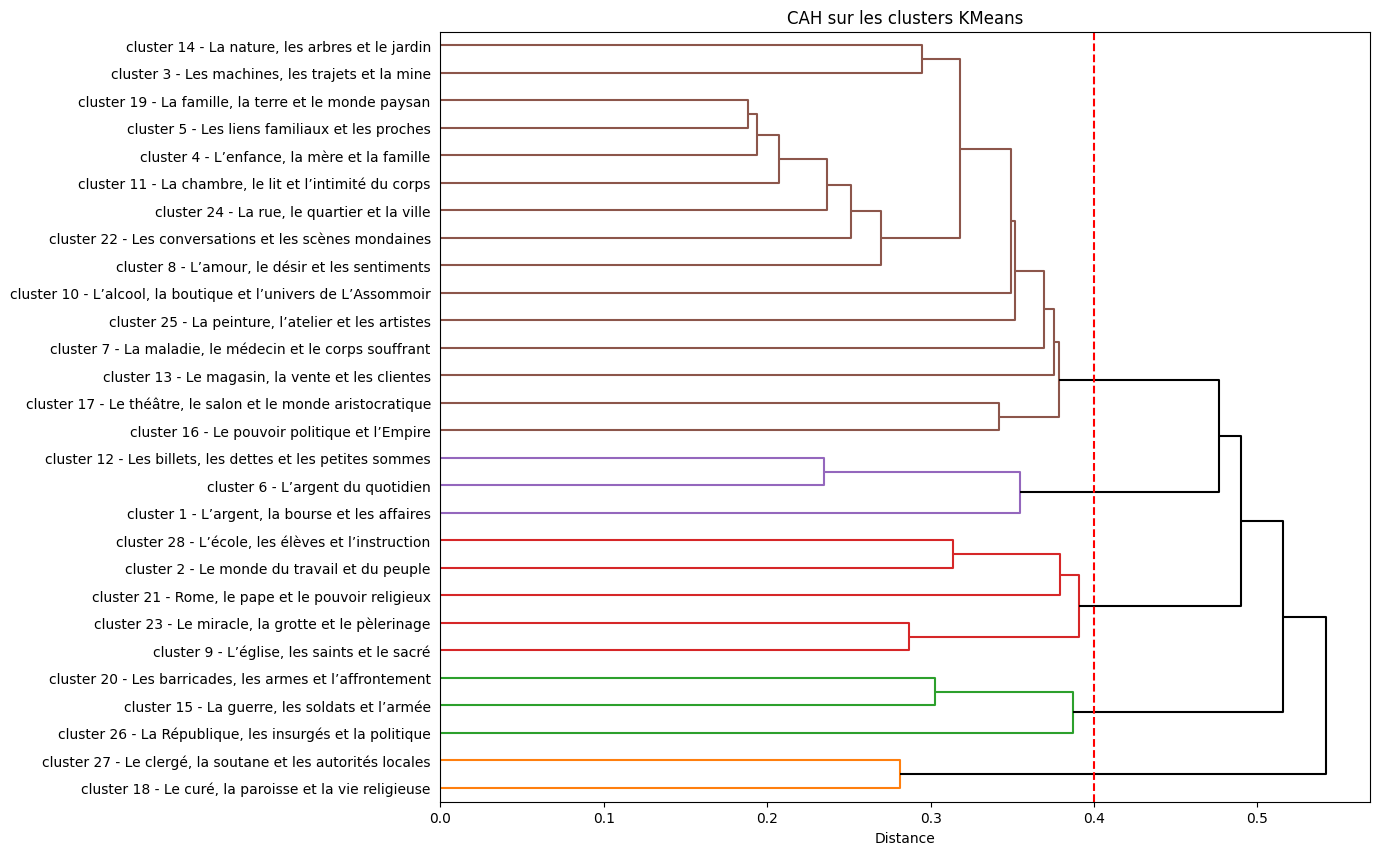

In [25]:
labels_clusters = [
    f"cluster {i} - {noms_clusters[i]}" 
    for i in range(1, kmeans.n_clusters + 1)
]

plt.figure(figsize=(12, 10))
Z = linkage(centres, method='ward')

dendrogram(
    Z,
    labels=labels_clusters,
    orientation="right",
    color_threshold=0.40,
    above_threshold_color="black"
)

plt.axvline(x=0.40, color="red", linestyle="--")

plt.title("CAH sur les clusters KMeans")
plt.xlabel("Distance")
plt.show()

In [35]:
groupes_cah = fcluster(Z, t=0.40, criterion="distance")

df_groupes = pd.DataFrame({
    "cluster": range(1, kmeans.n_clusters + 1),
    "groupe_cah": groupes_cah
})

df_groupes["nom_cluster"] = df_groupes["cluster"].map(noms_clusters)

df_groupes.sort_values("groupe_cah")

,cluster,groupe_cah,nom_cluster
17,18,1,"Le curé, la paroisse et la vie religieuse"
26,27,1,"Le clergé, la soutane et les autorités locales"
25,26,2,"La République, les insurgés et la politique"
19,20,2,"Les barricades, les armes et l’affrontement"
14,15,2,"La guerre, les soldats et l’armée"
27,28,3,"L’école, les élèves et l’instruction"
1,2,3,Le monde du travail et du peuple
22,23,3,"Le miracle, la grotte et le pèlerinage"
20,21,3,"Rome, le pape et le pouvoir religieux"
8,9,3,"L’église, les saints et le sacré"


In [36]:
for groupe, data in df_groupes.groupby("groupe_cah"):
    print(f"\nGroupe {groupe}")
    for _, row in data.iterrows():
        print(f"- Cluster {row['cluster']} : {row['nom_cluster']}")


Groupe 1
- Cluster 18 : Le curé, la paroisse et la vie religieuse
- Cluster 27 : Le clergé, la soutane et les autorités locales

Groupe 2
- Cluster 15 : La guerre, les soldats et l’armée
- Cluster 20 : Les barricades, les armes et l’affrontement
- Cluster 26 : La République, les insurgés et la politique

Groupe 3
- Cluster 2 : Le monde du travail et du peuple
- Cluster 9 : L’église, les saints et le sacré
- Cluster 21 : Rome, le pape et le pouvoir religieux
- Cluster 23 : Le miracle, la grotte et le pèlerinage
- Cluster 28 : L’école, les élèves et l’instruction

Groupe 4
- Cluster 1 : L’argent, la bourse et les affaires
- Cluster 6 : L’argent du quotidien
- Cluster 12 : Les billets, les dettes et les petites sommes

Groupe 5
- Cluster 3 : Les machines, les trajets et la mine
- Cluster 4 : L’enfance, la mère et la famille
- Cluster 5 : Les liens familiaux et les proches
- Cluster 7 : La maladie, le médecin et le corps souffrant
- Cluster 8 : L’amour, le désir et les sentiments
- Cluste

In [37]:
noms_groupes_cah = {
    1: "Religion locale et autorité cléricale",
    2: "Guerre, insurrection et conflit politique",
    3: "Institutions, croyances et encadrement social",
    4: "Argent, dettes et circulation financière",
    5: "Vie quotidienne, espaces sociaux et expériences individuelles"
}


In [38]:
df_groupes["nom_groupe_cah"] = df_groupes["groupe_cah"].map(noms_groupes_cah)

In [39]:
cluster_vers_groupe = dict(zip(df_groupes["cluster"], df_groupes["groupe_cah"]))

df["groupe_cah"] = df["cluster"].map(cluster_vers_groupe)
df["nom_groupe_cah"] = df["groupe_cah"].map(noms_groupes_cah)

In [40]:
df.head()

,nom_fichier,id_paquet,phrases_paquet,phrases_lemm,cluster,nom_cluster,groupe_cah,nom_groupe_cah
0,1893_20_Le_docteur_Pascal._clean.txt,0,Dans la chaleur de l’ardente après-midi de jui...,chaleur ardent après-midi juillet salle volet ...,24,"La rue, le quartier et la ville",5,"Vie quotidienne, espaces sociaux et expérience..."
1,1893_20_Le_docteur_Pascal._clean.txt,1,"Mais il dut prendre une chaise, la planche du ...",chaise planche haut haut grand taille planche ...,7,"La maladie, le médecin et le corps souffrant",5,"Vie quotidienne, espaces sociaux et expérience..."
2,1893_20_Le_docteur_Pascal._clean.txt,2,"Oh! Monsieur, la religion n’a jamais fait de m...",monsieur religion mal idée sûr silence diverge...,4,"L’enfance, la mère et la famille",5,"Vie quotidienne, espaces sociaux et expérience..."
3,1893_20_Le_docteur_Pascal._clean.txt,3,"De face, dans son visage séché, ses yeux garda...",face visage oeil flamme joli sourir grand-mère...,26,"La République, les insurgés et la politique",2,"Guerre, insurrection et conflit politique"
4,1893_20_Le_docteur_Pascal._clean.txt,4,s’écria la jeune fille. Mais elle était lancée...,jeune fille bon femme fond faubourg pile mort ...,5,Les liens familiaux et les proches,5,"Vie quotidienne, espaces sociaux et expérience..."


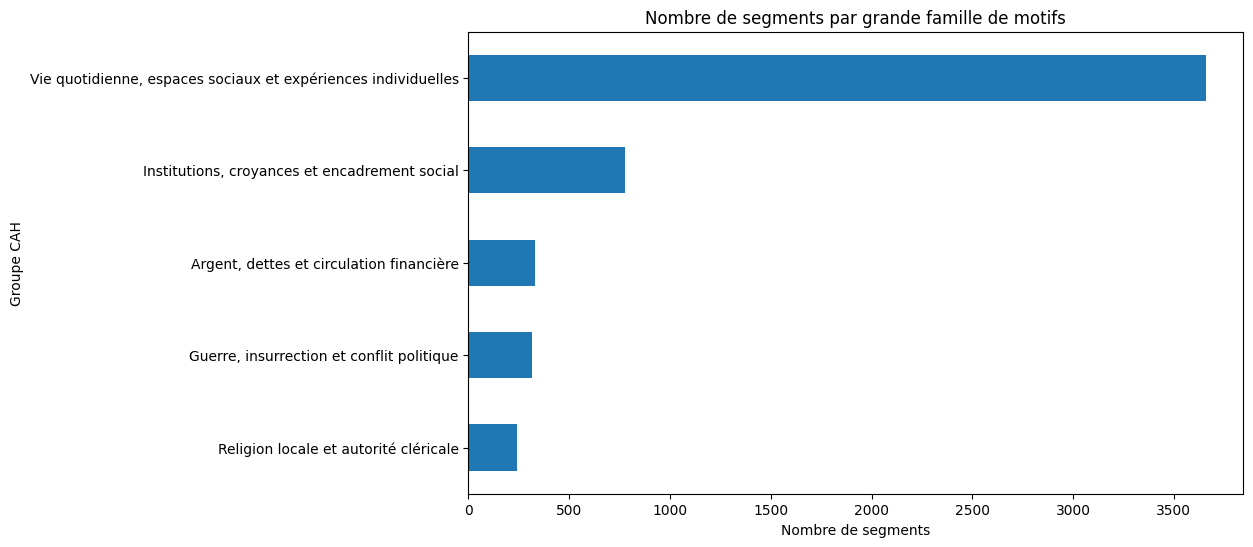

In [41]:
import matplotlib.pyplot as plt

counts = df["nom_groupe_cah"].value_counts().sort_values()

plt.figure(figsize=(10, 6))
counts.plot(kind="barh")

plt.title("Nombre de segments par grande famille de motifs")
plt.xlabel("Nombre de segments")
plt.ylabel("Groupe CAH")
plt.show()

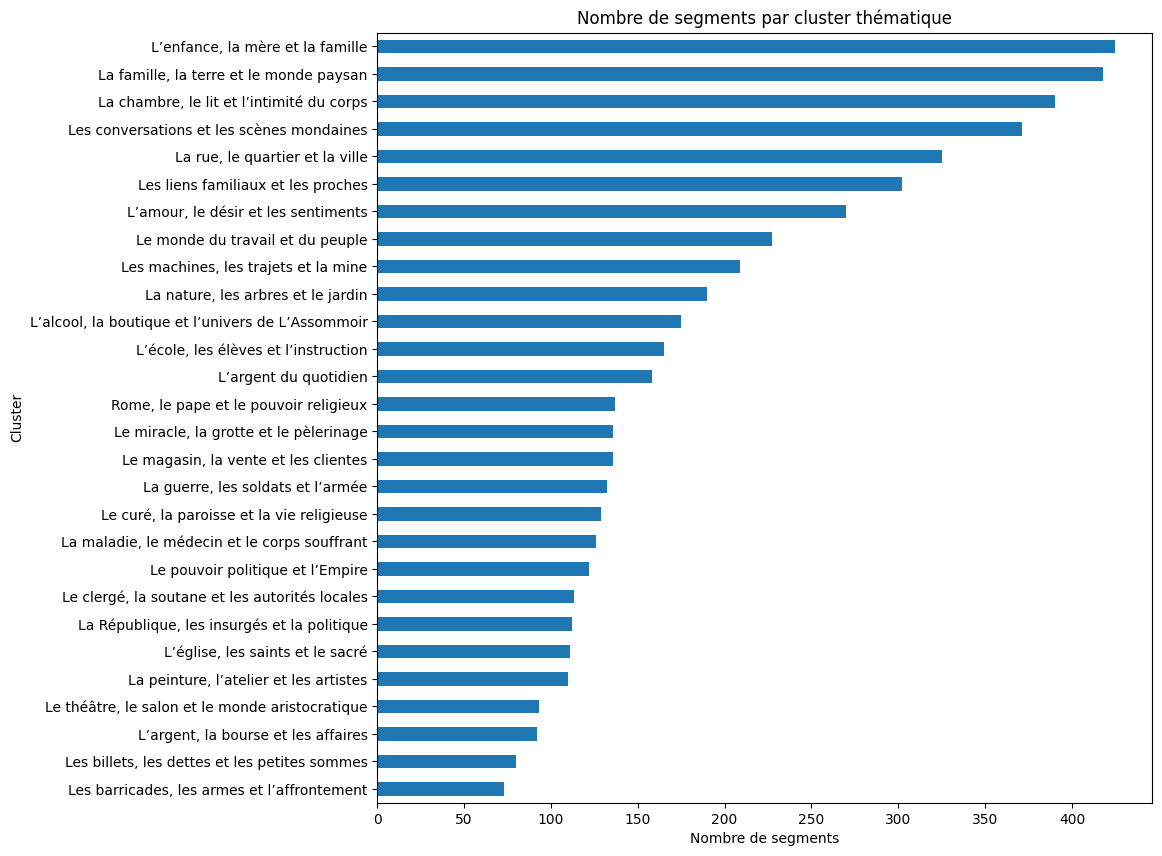

In [42]:
counts = df["nom_cluster"].value_counts().sort_values()

plt.figure(figsize=(10, 10))
counts.plot(kind="barh")

plt.title("Nombre de segments par cluster thématique")
plt.xlabel("Nombre de segments")
plt.ylabel("Cluster")
plt.show()

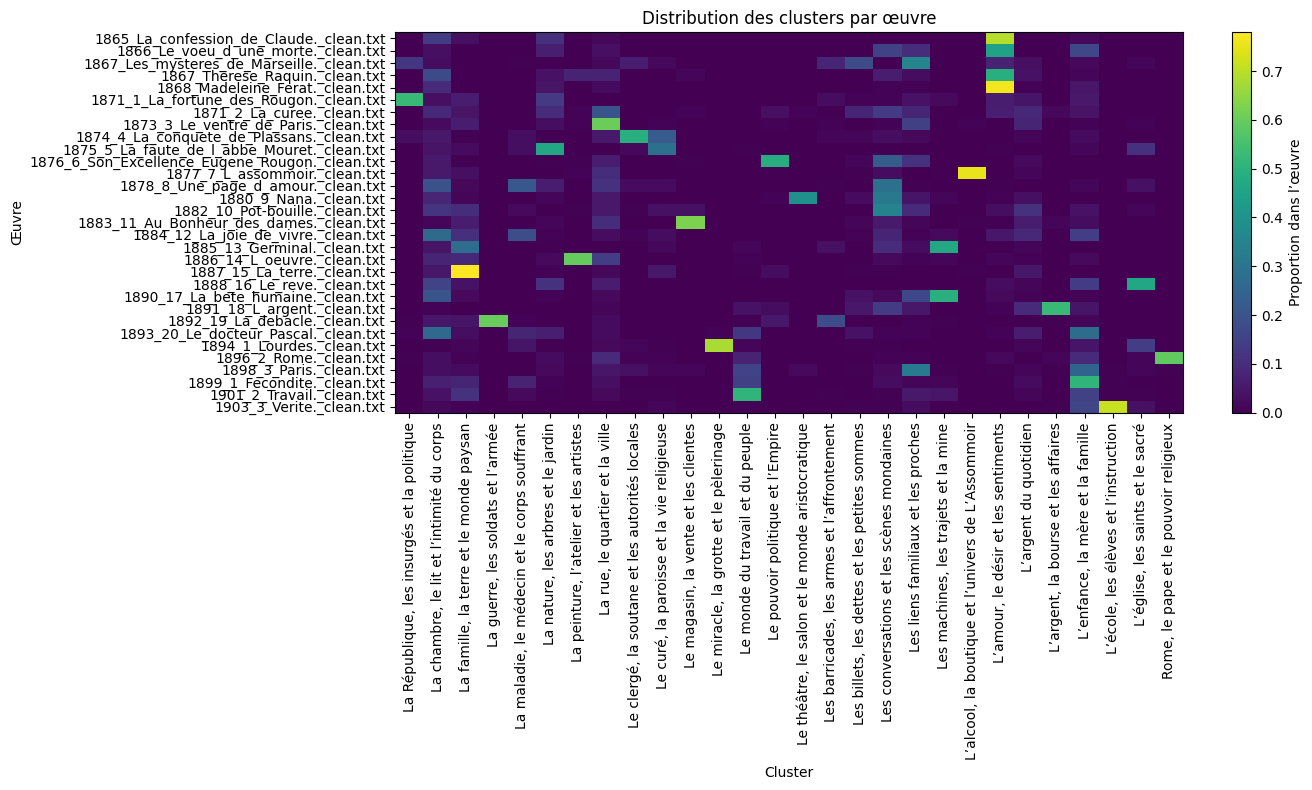

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

table = pd.crosstab(
    df["nom_fichier"],
    df["nom_cluster"],
    normalize="index"
)

plt.figure(figsize=(14, 8))
plt.imshow(table, aspect="auto")

plt.xticks(range(len(table.columns)), table.columns, rotation=90)
plt.yticks(range(len(table.index)), table.index)

plt.title("Distribution des clusters par œuvre")
plt.xlabel("Cluster")
plt.ylabel("Œuvre")
plt.colorbar(label="Proportion dans l’œuvre")
plt.tight_layout()
plt.show()

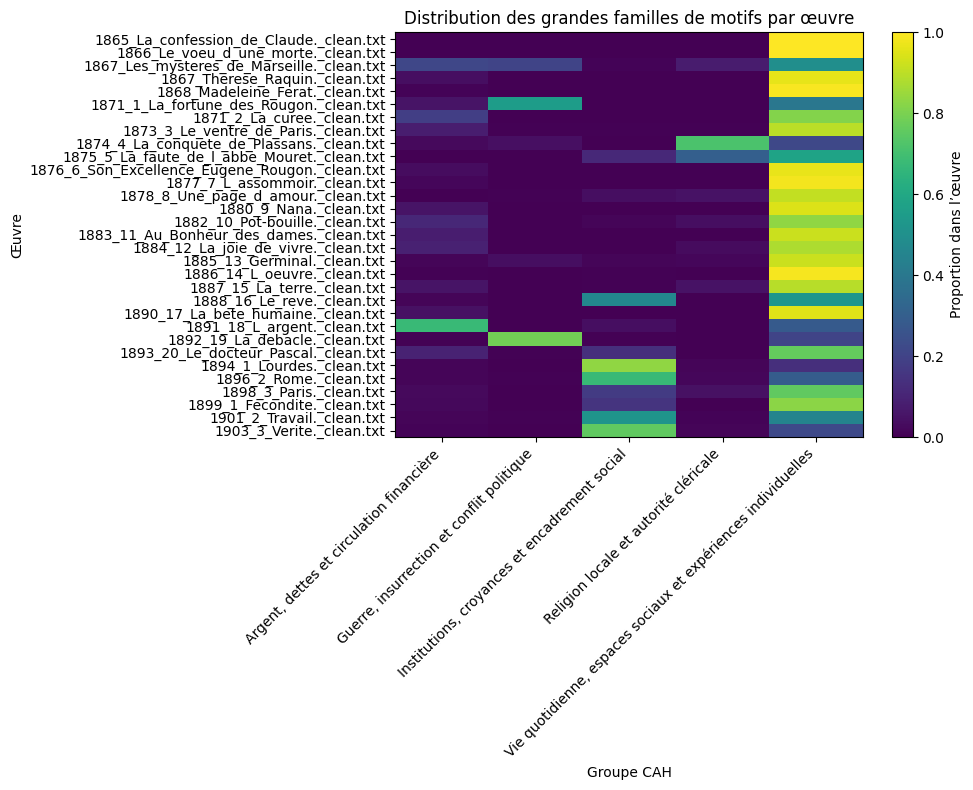

In [44]:
table_groupes = pd.crosstab(
    df["nom_fichier"],
    df["nom_groupe_cah"],
    normalize="index"
)

plt.figure(figsize=(10, 8))
plt.imshow(table_groupes, aspect="auto")

plt.xticks(range(len(table_groupes.columns)), table_groupes.columns, rotation=45, ha="right")
plt.yticks(range(len(table_groupes.index)), table_groupes.index)

plt.title("Distribution des grandes familles de motifs par œuvre")
plt.xlabel("Groupe CAH")
plt.ylabel("Œuvre")
plt.colorbar(label="Proportion dans l’œuvre")
plt.tight_layout()
plt.show()

/Users/morganr/analyse_topic_zola/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


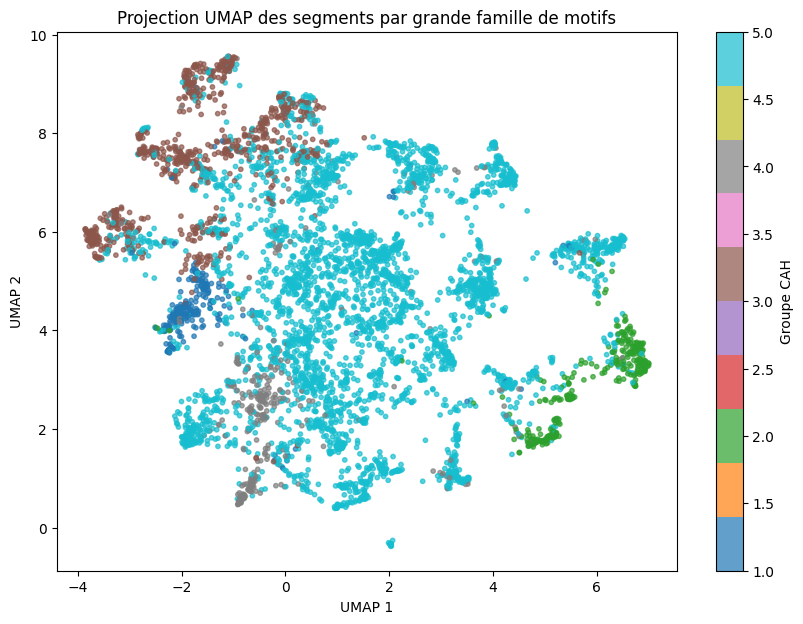

In [47]:
import umap.umap_ as umap

# X doit être la matrice numérique utilisée pour représenter tes segments
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X)

plt.figure(figsize=(10, 7))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=df["groupe_cah"],
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.title("Projection UMAP des segments par grande famille de motifs")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(label="Groupe CAH")
plt.show()